# Advanced Artificial Intelligence Task 2
### Produce classification via pre-trained models across different architectures

- **CNN**:          
    - EfficientNet_V2_S_Weights.IMAGENET1K_V1
- **TRANSFORMER**
    - Swin_S_Weights.IMAGENET1K_V1 
- **HYBRID**
    - MaxVit_T 

Details for the pre-trained weights can be found [here](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_v2_s.html#torchvision.models.efficientnet_v2_s).

In [1]:
%load_ext tensorboard
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import os
import matplotlib.pyplot as plt
import random
import torch.optim as optim
import torchmetrics
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from pathlib import Path
import datetime


PRODUCE_PATH = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
WORKERS = os.cpu_count()

# TRANSFER LEARNING APPROACH
TRANSFER_TYPE = "FREEZE"  # "FREEZE", "FINETUNE"

# HYPERPARAMETERS
LEARNING_RATE = 1e-3
MOMENTUM = 0.9
SPLIT = 0.8 
BATCH_SIZE = 32
EPOCHS = 5

# Define model and pre-trained IMAGENET weights (as defined in link above)
# Load the pre-trained weights and extract required transformations for model image input
WEIGHTS = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
PRETRAINED_MODEL = models.efficientnet_v2_s(weights=WEIGHTS)
NUM_CLASSES = 2
auto_transforms = WEIGHTS.transforms()
print(WEIGHTS.meta)
WEIGHTS.transforms()


{'categories': ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

0 torch.Size([3, 384, 384]) 0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8081232..1.8036647].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.405462..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.2042704].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


1 torch.Size([3, 384, 384]) 1
2 torch.Size([3, 384, 384]) 1
3 torch.Size([3, 384, 384]) 0
4 torch.Size([3, 384, 384]) 1


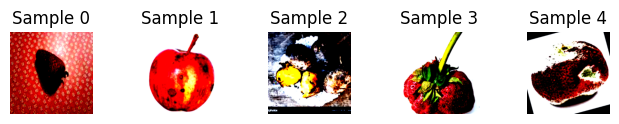

In [2]:
# Class for building Dataset object
# https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html#dataset-class

class ProduceDataset(Dataset):
    "Produce dataset for binary classification of healthy vs rotten produce"

    def __init__(self, root_dir, transform=None):
        """
        Arguments:
            root_dir (string): Directory with all the images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.assign_labels()

    def assign_labels(self):
        """
        Assigns labels to images based on directory names (Healthy vs Rotten)
        0 = Healthy; 1 = Rotten        
        """
        for folder_name in os.listdir(self.root_dir):
            folder_path = os.path.join(self.root_dir, folder_name)
            if os.path.isdir(folder_path):
                label = 0 if "Healthy" in folder_name else 1
                
                for img_name in os.listdir(folder_path):
                    self.image_paths.append(os.path.join(folder_path, img_name))
                    self.labels.append(label)
    
    def display_examples(self, num_samples=5):
        """
        Displays random n samples from the dataset with their corresponding labels.
        """
        random_indices = random.sample(range(len(self)), num_samples)
        random_samples = [self[id] for id in random_indices]
        for i, sample in enumerate(random_samples):
            print(i, sample[0].shape, sample[1])
            ax = plt.subplot(1, num_samples, i + 1)
            plt.tight_layout()
            ax.set_title('Sample {}'.format(i))
            ax.axis('off')
            # Pytorch transforms images to C, H, W. Matplot expects H, W, C => Permute for display
            # i.e [3, 384, 384] -> [384, 384, 3]
            plt.imshow(sample[0].permute(1, 2, 0))
            if i == num_samples - 1:
                plt.show()
                break

    def augment(self, sample):
        #TODO: Implement data augmentioned transformations (e.g. random horizontal flip, random rotation, etc.)
        # Part 4. https://medium.com/@ebimsv/mastering-cnns-in-pytorch-week-2-building-and-training-custom-and-pretrained-cnns-for-image-f040572c73c1
        pass

    def balance(self):
        #TODO: Implement data balancing - Weighted cross entropy loss or oversampling/undersampling techniques
        pass 

    def __len__(self):
        """Allows len(dataset) to return the size of the dataset"""
        return len(self.image_paths)

    def __getitem__(self, idx):
        """Allow support for indexing, e.g. dataset[0] to return the first sample and corresponding label."""
        if torch.is_tensor(idx):
            idx = idx.tolist()

        image_path = self.image_paths[idx]
        # Ensure image is RGB (some images have 4 channels)
        sample = Image.open(image_path).convert('RGBA').convert('RGB') 
        label = self.labels[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label
    
    
# Initialize the dataset and assign labels based on folder structure

produce_dataset = ProduceDataset(root_dir=PRODUCE_PATH, transform=auto_transforms)
produce_dataset.display_examples(num_samples=5)


# Transfer Learning vs. Finetuning
Both methods implement a classifer head (the final layer) for the new task (Healthy vs. Rotten). They adapt pre-trained model behaviour in distinct ways:
| Method | Description | When to use? |
|---|---|---|
| Transfer learning | Freeze most or all pre-trained weights and train new classifer head. | Small dataset, similar domain and task. |
| Fine-tuning | Update some or all model weights as well as new classifier head.| Large dataset, less similar domain and task |


In [3]:
# https://medium.com/@marklpd/transfer-learning-finetuning-for-cnns-in-pytorch-5c4ade873d93
# Freeze weights of all layers except the final classification head
if TRANSFER_TYPE == "FREEZE":
    for parameters in PRETRAINED_MODEL.parameters():
        parameters.requires_grad = False # Do not compute gradients (i.e., freeze weights)

# Modify final classificaiton head from 1000 => 2 Classes (Healthy vs Rotten)
# Gradients are enabled by default for new layers.
num_features = PRETRAINED_MODEL.classifier[1].in_features
PRETRAINED_MODEL.classifier[1] = nn.Linear(num_features, NUM_CLASSES)

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRETRAINED_MODEL = PRETRAINED_MODEL.to(device)

# print(PRETRAINED_MODEL)


In [4]:
# DEFINE LOSS FUNCTION, OPTIMIZER AND LEARNING RATE SCHEDULER
# Multi-class loss function
criterion = nn.CrossEntropyLoss()

# Stochastic Gradient Descent optimizer - Pass new classifer parameters only (if freezing base model)
# TODO - Verify this functionality
if TRANSFER_TYPE == "FREEZE":
    optimizer = optim.SGD(PRETRAINED_MODEL.classifier.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)
else:
    optimizer = optim.SGD(PRETRAINED_MODEL.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# Learning rate scheduler 
# Decay LR by a factor of 0.1 every 5 epochs
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [5]:
# SPLIT DATASET INTO TRAIN AND VALIDATION
generator = torch.Generator().manual_seed(42) # Set seed for reproducibility
total_size = len(produce_dataset)
train_size = int(SPLIT * total_size)
val_size = total_size - train_size
train_dataset, val_dataset = torch.utils.data.random_split(produce_dataset, [train_size, val_size], generator=generator)

# INTIALIZE DATALOADERS - https://www.geeksforgeeks.org/deep-learning/pytorch-dataloader/
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=WORKERS) # Shuffle training data for better generalization
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=WORKERS) # No need to shuffle validation data 

print(f"Training size: {train_size} images\nValidation size: {val_size} images.")

Training size: 23432 images
Validation size: 5859 images.


In [6]:
# TRAIN/VALIDATION LOOP
# https://medium.com/@ebimsv/mastering-cnns-in-pytorch-week-2-building-and-training-custom-and-pretrained-cnns-for-image-f040572c73c1

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0
        self.count = 0

    def update(self, value, n=1):
        self.sum += value * n
        self.count += n

    @property
    def avg(self):
        return self.sum / self.count if self.count > 0 else 0

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch, accuracy_metric):
    model.train()
    loss_meter = AverageMeter()
    accuracy_metric.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Training]", leave=False)

    for id, (X_batch, y_batch) in enumerate(progress_bar):
        # Move data to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Zero gradients to not accumulate from previous batch
        optimizer.zero_grad()

        # Calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()


        # Update metrics
        loss_meter.update(loss.item(), X_batch.size(0))
        preds = outputs.argmax(dim=1)
        accuracy_metric.update(preds, y_batch)

        if id % 50 == 0:
            progress_bar.set_postfix(loss=loss_meter.avg, accuracy=accuracy_metric.compute().item())

    avg_loss = loss_meter.avg
    avg_accuracy = accuracy_metric.compute().item()

    return avg_loss, avg_accuracy

def validate(model, dataloader, criterion, device, epoch, accuracy_metric):
    model.eval()
    loss_meter = AverageMeter()
    accuracy_metric.reset()
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} [Validation]", leave=False)
    
    # Disable gradient descent for validation
    with torch.no_grad():
        for id, (X_batch, y_batch) in enumerate(progress_bar):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            # Update loss and accuracy
            loss_meter.update(loss.item(), X_batch.size(0))
            preds = outputs.argmax(dim=1)
            accuracy_metric.update(preds, y_batch)

            if id % 50 == 0:
                    progress_bar.set_postfix(loss=loss_meter.avg, accuracy=accuracy_metric.compute().item())
        
    avg_loss = loss_meter.avg
    avg_accuracy = accuracy_metric.compute().item()
    
    return avg_loss, avg_accuracy

writer = SummaryWriter()

# Set accuracy metrics
train_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)
val_accuracy = torchmetrics.Accuracy(task="binary", num_classes=NUM_CLASSES).to(device)

name = WEIGHTS.__class__.__name__
base_name = name.replace("_Weights" , '')
timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M%S")
model_save_name = f"{base_name}_{timestamp}"

best_val_acc = 0.0
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(PRETRAINED_MODEL, train_loader, criterion, optimizer, device, epoch, train_accuracy)
    val_loss, val_acc = validate(PRETRAINED_MODEL, val_loader, criterion, device, epoch, val_accuracy)

    # Step scheduler at each epoch
    lr_scheduler.step()

    # Log metrics to TensorBoard  
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('Accuracy/Validation', val_acc, epoch)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f"New best model saved with Val Acc: {best_val_acc:.4f}")
        torch.save(PRETRAINED_MODEL.state_dict(), f'models/{model_save_name}.pth')
writer.close()


New best model saved with Val Acc: 0.8812


New best model saved with Val Acc: 0.8950


New best model saved with Val Acc: 0.9013


New best model saved with Val Acc: 0.9073
